In [1]:
# GTA V Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#  1.Load and Cleaning Dataset

In [3]:

df = pd.read_csv(r"C:\Users\tiwar\Downloads\Projects\GTA_V_Raw Dataset.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   14780 non-null  object 
 1   year                             14780 non-null  int64  
 2   month                            14780 non-null  int64  
 3   quarter                          14780 non-null  int64  
 4   country                          14780 non-null  object 
 5   iso3_code                        14780 non-null  object 
 6   region                           14780 non-null  object 
 7   platform                         14780 non-null  object 
 8   game_edition                     14780 non-null  object 
 9   sales_channel                    14780 non-null  object 
 10  retailer                         14780 non-null  object 
 11  units_sold                       14780 non-null  int64  
 12  gross_revenue_usd 

,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,...,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,top_game_category,platform_generation
0,GTA5-100039,2013,9,3,Algeria,DZA,Africa,PS3,Premium Edition,Physical,...,4.82,38.28,5621.76,Launch,41.4,58.6,Autumn,Xbox Sale,Action-Adventure,Gen7
1,GTA5-100005,2013,9,3,Argentina,ARG,South America,PS3,Standard Edition,Physical,...,23.48,42.31,14452.74,Launch,40.8,59.2,Autumn,Xbox Sale,Action-Adventure,Gen7
2,GTA5-100093,2013,9,3,Argentina,ARG,South America,Xbox 360,Premium Edition,Physical,...,23.96,42.31,14748.61,Launch,51.6,48.4,Autumn,Xbox Sale,Action-Adventure,Gen7
3,GTA5-100072,2013,9,3,Armenia,ARM,Asia,PS3,Standard Edition,Physical,...,0.14,2.92,3879.16,Launch,42.3,57.7,Autumn,Xbox Sale,Action-Adventure,Gen7
4,GTA5-100034,2013,9,3,Australia,AUS,Oceania,PS3,Legacy Edition,Physical,...,231.44,23.17,69365.83,Launch,43.4,56.6,Autumn,Xbox Sale,Action-Adventure,Gen7


In [ ]:
df.describe()

In [68]:
df.dtypes

transaction_id                      object
year                                 int64
month                                int64
quarter                              int64
country                             object
iso3_code                           object
region                              object
platform                            object
game_edition                        object
sales_channel                       object
retailer                            object
units_sold                           int64
gross_revenue_usd                  float64
average_selling_price_usd          float64
discount_percentage                float64
digital_sales_percentage           float64
physical_sales_percentage          float64
new_customers                        int64
returning_customers                  int64
estimated_active_players             int64
peak_concurrent_players              int64
online_players                       int64
story_mode_players                   int64
gta_online_

In [54]:
df.isnull().sum()
# Found 3432 Null Values in major_sale_event column and 3344 Null Values in special_event column.

In [52]:
df['special_event'] = df['special_event'].fillna('No Event')
df['major_sale_event'] = df['major_sale_event'].fillna('No Event')

In [57]:
df['date'] = pd.to_datetime(
    df[['year','month']].assign(day=1)
)
# Create a date column from the 'year' and 'month' fields by assigning the first day of each month.
#This enables time-based analysis and visualization.

In [56]:
(df['digital_sales_percentage'] +
 df['physical_sales_percentage']).describe()
# Check whether digital and physical sales percentages add up to 100%.

count    14780.0
mean       100.0
std          0.0
min        100.0
25%        100.0
50%        100.0
75%        100.0
max        100.0
dtype: float64

In [66]:
df['transaction_id'].duplicated().sum()
#Checking for Dublicate Values

np.int64(0)

In [5]:
columns = [
    'gross_revenue_usd', 'units_sold', 'discount_percentage',
    'new_customers', 'customer_rating', 'average_playtime_hours',
    'gta_online_players', 'shark_card_revenue_usd',
    'gdp_per_capita_usd', 'internet_penetration_percentage',
    'refund_rate_percentage', 'digital_sales_percentage',
    'physical_sales_percentage'
]

(df[columns] < 0).sum()

#Checking for Negative Values

gross_revenue_usd                  0
units_sold                         0
discount_percentage                0
new_customers                      0
customer_rating                    0
average_playtime_hours             0
gta_online_players                 0
shark_card_revenue_usd             0
gdp_per_capita_usd                 0
internet_penetration_percentage    0
refund_rate_percentage             0
digital_sales_percentage           0
physical_sales_percentage          0
dtype: int64

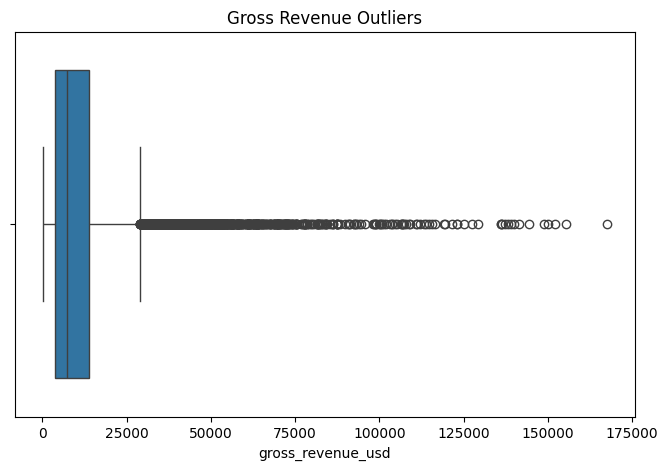

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['gross_revenue_usd'])
plt.title("Gross Revenue Outliers")
plt.show()
#Checking for Outliers

In [ ]:
#  2.Correlation heatmap

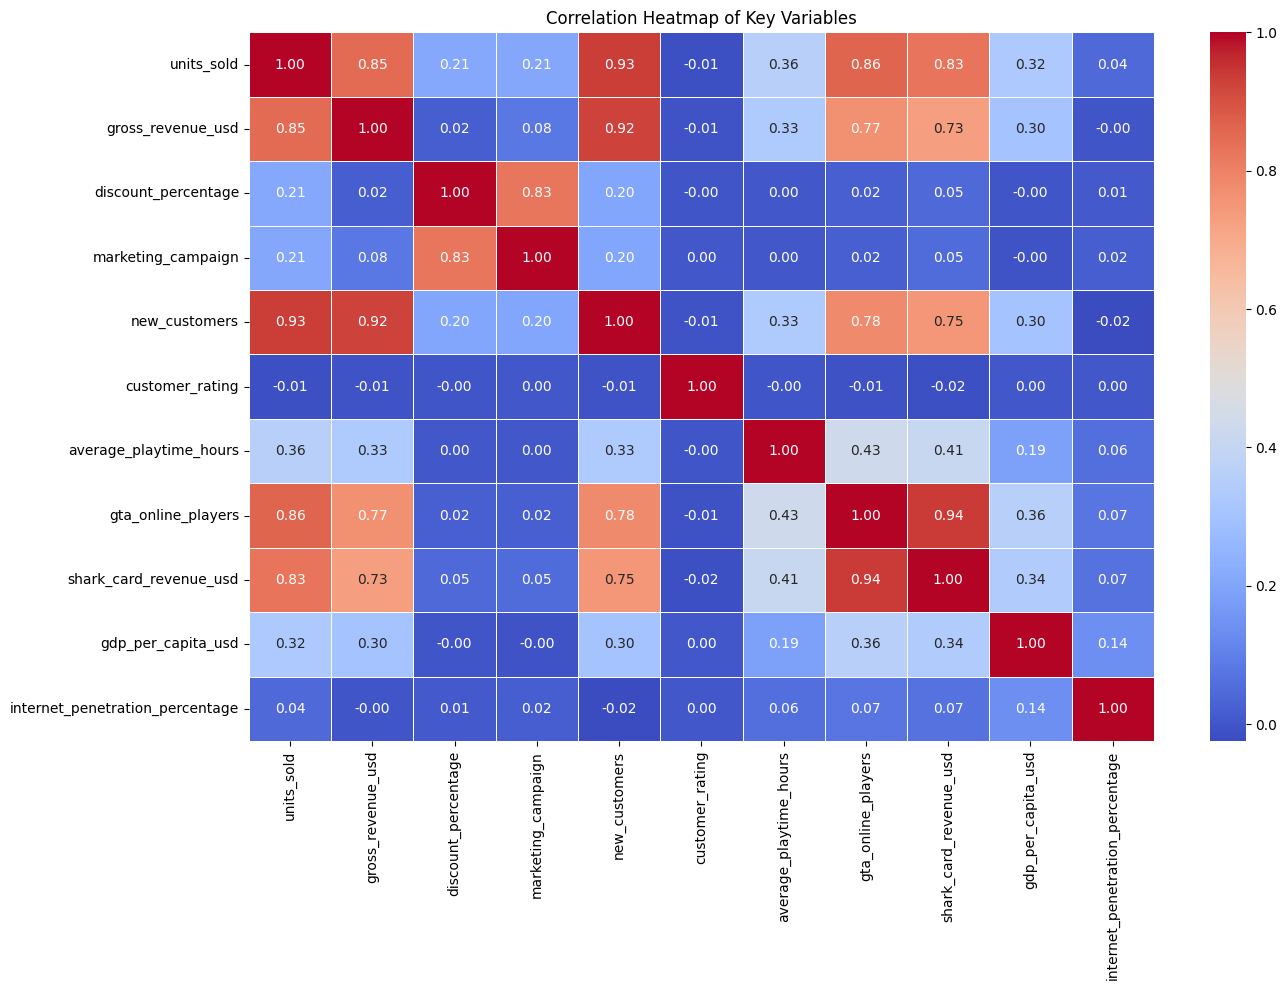

In [4]:
#Selecting Columns
corr_columns = [
    'units_sold',
    'gross_revenue_usd',
    'discount_percentage',
    'marketing_campaign',
    'new_customers',
    'customer_rating',
    'average_playtime_hours',
    'gta_online_players',
    'shark_card_revenue_usd',
    'gdp_per_capita_usd',
    'internet_penetration_percentage'
]

# Calculate correlation
correlation = df[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.show()

In [ ]:
#  3.Segment Analysis

In [8]:
# A. Sales Channel Analysis
channel_analysis = (
    df.groupby('sales_channel')[
        ['gross_revenue_usd',
         'units_sold',
         'refund_rate_percentage']
    ]
    .mean()
    .sort_values('gross_revenue_usd', ascending=False)
)
print(channel_analysis)
# Calculating  Average Revenue, Units Sold, and Refund Rate for each Sales Channel.

               gross_revenue_usd  units_sold  refund_rate_percentage
sales_channel                                                       
Physical            14750.376476  738.688992                3.494033
Digital             10348.973125  893.424115                3.487629


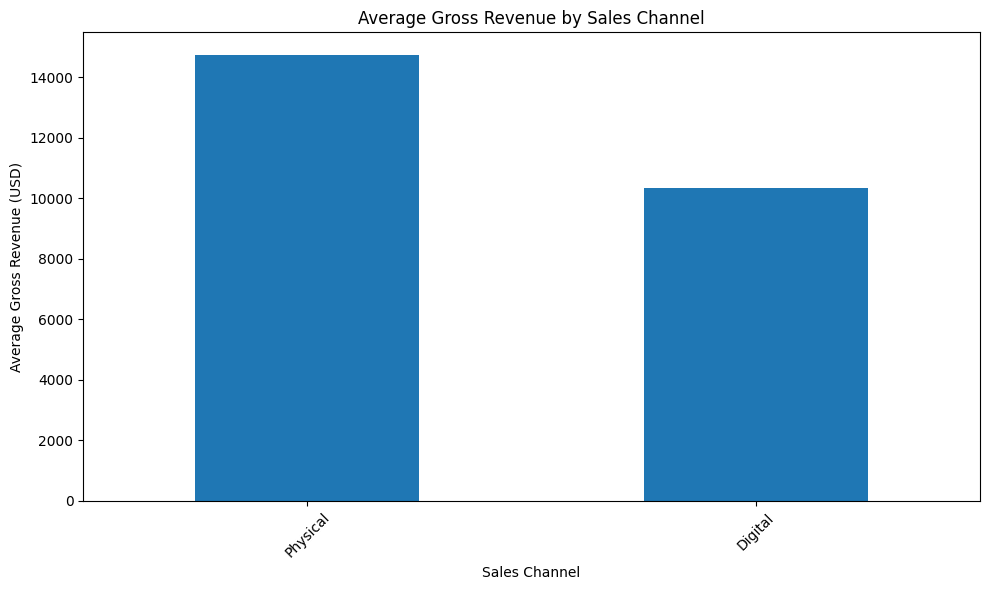

In [9]:
# Visualization
channel_analysis['gross_revenue_usd'].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Gross Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Average Gross Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# B. Region vs Macroeconomic Factors
region_analysis = (
    df.groupby('region')[
        ['gross_revenue_usd',
         'internet_penetration_percentage',
         'gdp_per_capita_usd']
    ]
    .mean()
    .sort_values('gross_revenue_usd', ascending=False)
)

region_analysis
# Calculating Average Revenue, Internet Penetration, and GDP per Capita by Region

,gross_revenue_usd,internet_penetration_percentage,gdp_per_capita_usd
region,,,
North America,32812.658191,97.060967,43222.234734
Oceania,13529.249978,96.950216,40663.186429
Europe,12497.891182,97.244637,37984.919432
Asia,10518.757447,96.453693,19427.013766
South America,6352.444875,96.323420,12996.232767
Africa,5835.333449,95.828066,4192.915967


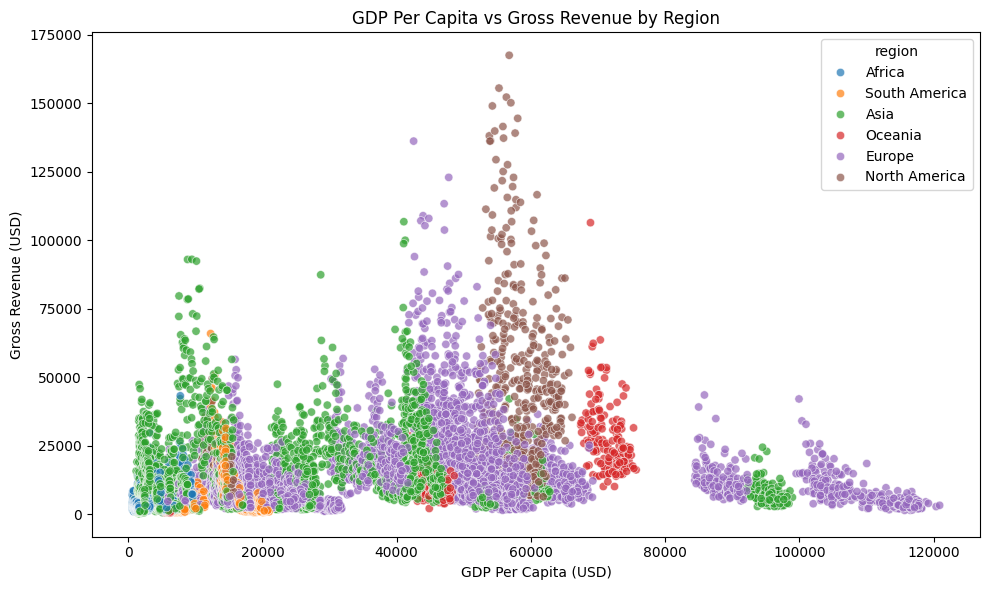

In [11]:
#  C. GDP vs Revenue Scatter Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='gdp_per_capita_usd',
    y='gross_revenue_usd',
    hue='region',
    alpha=0.7
)

plt.title('GDP Per Capita vs Gross Revenue by Region')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Gross Revenue (USD)')
plt.tight_layout()
plt.show()

In [ ]:
#  4.Time-Series & Seasonality

In [11]:
# A.Revenue Over Time

df['date'] = pd.to_datetime(
    df[['year', 'month']].assign(day=1)
)

df = df.sort_values('date')
# Creating date column using year and month column


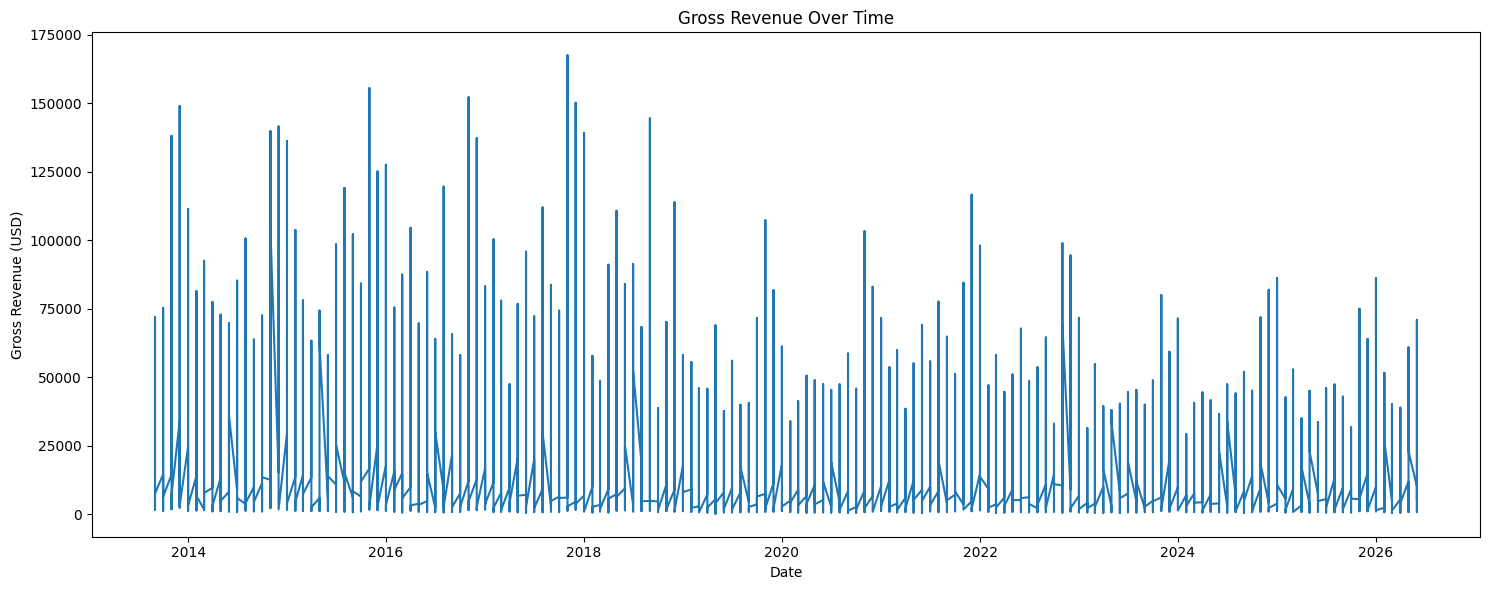

In [10]:
#Visualization
plt.figure(figsize=(15, 6))

plt.plot(
    df['date'],
    df['gross_revenue_usd']
)

plt.title('Gross Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Gross Revenue (USD)')

plt.tight_layout()
plt.show()

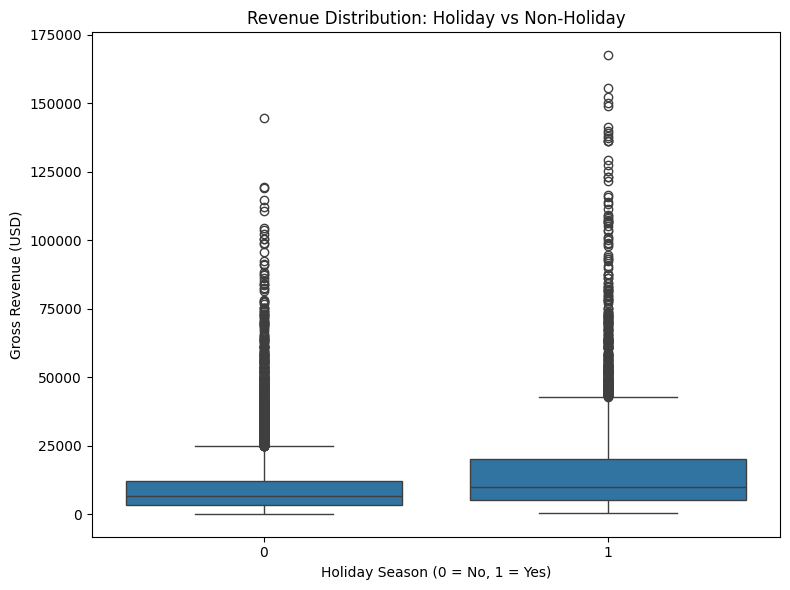

In [15]:
# B.Holiday vs Non-Holiday Revenue

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='holiday_season',
    y='gross_revenue_usd'
)

plt.title('Revenue Distribution: Holiday vs Non-Holiday')
plt.xlabel('Holiday Season (0 = No, 1 = Yes)')
plt.ylabel('Gross Revenue (USD)')

plt.tight_layout()
plt.show()

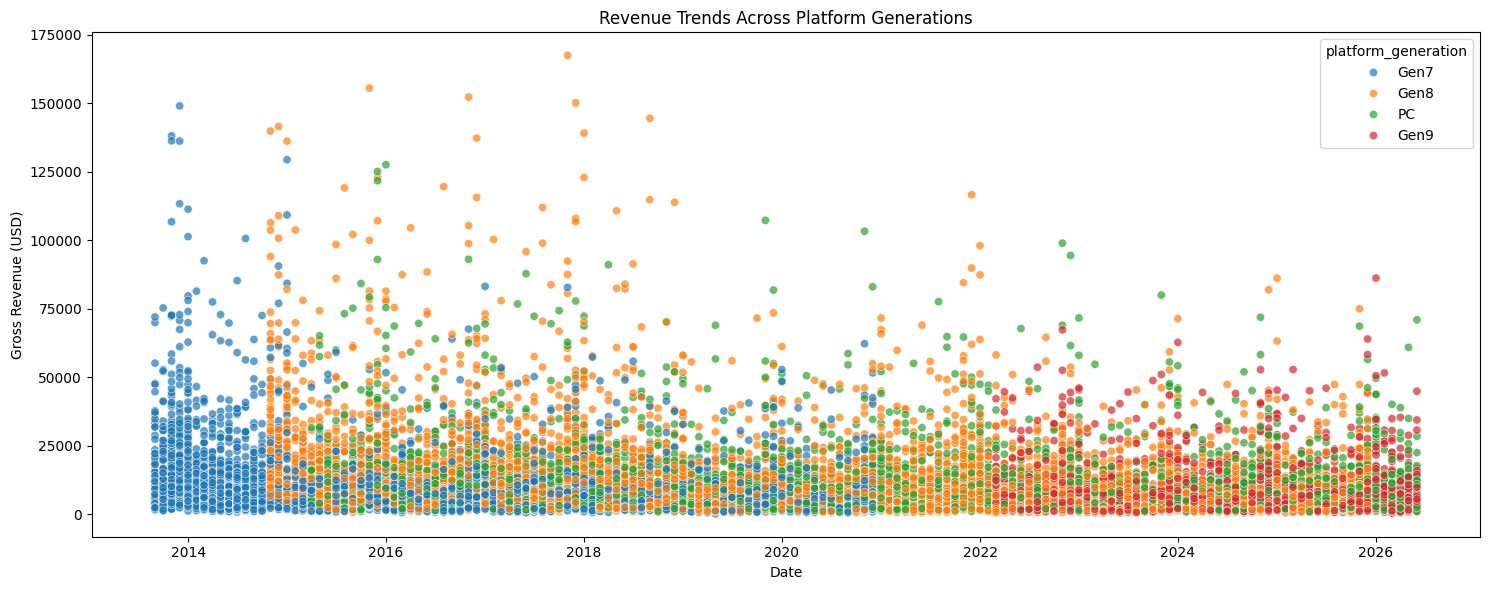

In [24]:
# C.Platform Generation Transitions

plt.figure(figsize=(15, 6))

sns.scatterplot(
    data=df,
    x='date',
    y='gross_revenue_usd',
    hue='platform_generation',
    alpha=0.7
)

plt.title('Revenue Trends Across Platform Generations')
plt.xlabel('Date')
plt.ylabel('Gross Revenue (USD)')

plt.tight_layout()
plt.show()

In [5]:
#  6. Forecasting Monthly Revenue

# Create date column from year and month
df['date'] = pd.to_datetime(
    df[['year', 'month']].assign(day=1)
)

# Calculate total revenue for each month
monthly_revenue = (
    df.set_index('date')
      .resample('ME')['gross_revenue_usd']
      .sum()
)

monthly_revenue.head()

date
2013-09-30    1442441.45
2013-10-31    1236215.25
2013-11-30    2376795.03
2013-12-31    2224411.12
2014-01-31    2195119.90
Freq: ME, Name: gross_revenue_usd, dtype: float64

In [11]:
from prophet import Prophet

# Convert to Prophet format
forecast_data = monthly_revenue.reset_index()

forecast_data.columns = ['ds', 'y']

# Create model
prophet_model = Prophet()

# Fit model
prophet_model.fit(forecast_data)

17:29:01 - cmdstanpy - INFO - Chain [1] start processing
17:29:01 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
# Create a 12-month forecast

future = prophet_model.make_future_dataframe(
    periods=12,
    freq='ME'
)

forecast = prophet_model.predict(future)

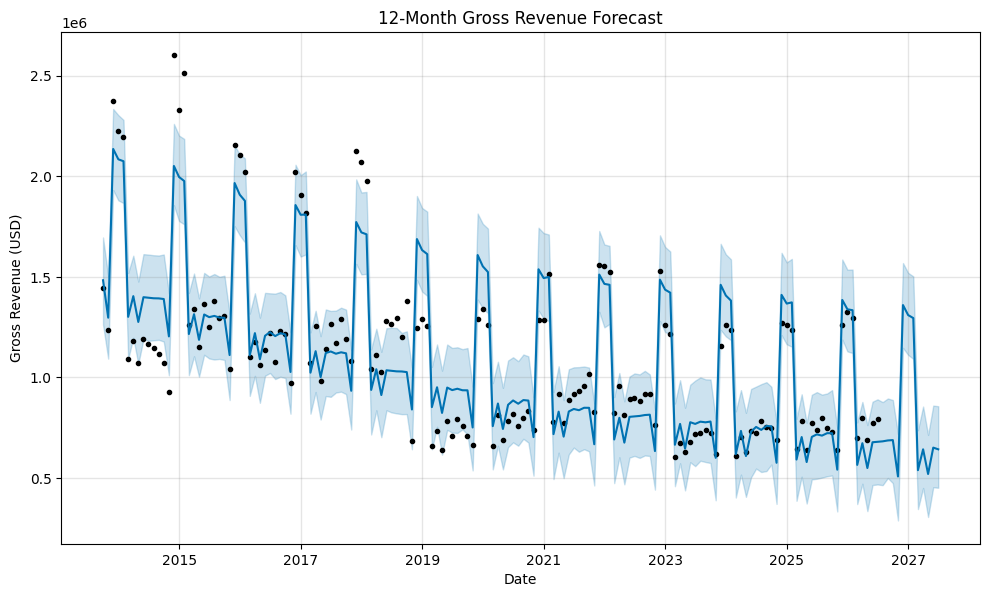

In [15]:
#Visualization

fig = prophet_model.plot(forecast)

plt.title('12-Month Gross Revenue Forecast')
plt.xlabel('Date')
plt.ylabel('Gross Revenue (USD)')

plt.show()

In [16]:
# forecast values

forecast[
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].tail(12)

# yhat → Expected revenue
# yhat_lower → Lower uncertainty estimate
# yhat_upper → Upper uncertainty estimate

,ds,yhat,yhat_lower,yhat_upper
154,2026-07-31,6.819753e+05,4.640606e+05,8.771329e+05
155,2026-08-31,6.864006e+05,4.996756e+05,8.951621e+05
156,2026-09-30,6.881672e+05,4.741994e+05,8.874394e+05
157,2026-10-31,5.072070e+05,2.884094e+05,7.175474e+05
158,2026-11-30,1.359801e+06,1.146941e+06,1.568815e+06
159,2026-12-31,1.309994e+06,1.112091e+06,1.520140e+06
160,2027-01-31,1.294990e+06,1.091965e+06,1.502468e+06
161,2027-02-28,5.386266e+05,3.449796e+05,7.372615e+05
162,2027-03-31,6.423098e+05,4.499007e+05,8.549605e+05
163,2027-04-30,5.194809e+05,3.055729e+05,7.139239e+05
